## Data Loading and Preprocessing

In [9]:
import pandas as pd

# Load the dataset
df = pd.read_csv("https://gitlab.crio.do/me_notebook/me_jupyter_bankattritionanalysis/-/raw/master/bank_dataset_v2.csv",header=0,skiprows=[1])

# Display the first few rows
print(df.head())

   Row Number Customer ID First Name        State  Gender  Age    Salary  \
0           2     MH00002      Nitya  Maharashtra  Female   77   33000.0   
1           3     KA00003     Vivaan    Karnataka    Male   78  190000.0   
2           4     MH00004     Dinesh  Maharashtra    Male   42  330000.0   
3           5     KA00005     Charvi    Karnataka  Female   29  155000.0   
4           6     DL00006      Aditi        Delhi  Female   38  111000.0   

   Credit Score  Tenure    Balance  ...  HasLoan HasFD  Num Of Products  \
0           538       4       0.00  ...        0     0                1   
1           531       8   15585.55  ...        0     1                2   
2           718       3  155688.22  ...        0     1                2   
3           710       7   89415.53  ...        0     1                2   
4           729       2   36613.80  ...        1     0                2   

   IsActiveMember  Exited  Complain  Count of Complains  Satisfaction Score  \
0            

In [10]:
# Print the column names of the dataset.
print(df.columns) 

Index(['Row Number', 'Customer ID', 'First Name', 'State', 'Gender', 'Age',
       'Salary', 'Credit Score', 'Tenure', 'Balance', 'HasCrCard', 'Card Type',
       'HasLoan', 'HasFD', 'Num Of Products', 'IsActiveMember', 'Exited',
       'Complain', 'Count of Complains', 'Satisfaction Score', 'Point Earned',
       'Preferred Channel'],
      dtype='object')


In [11]:
# Standardize the column names: convert to lowercase and replace spaces with underscores.

# Replacing all spaces with underscore(_) and converting the entire string to lowercase

df.columns = df.columns.str.lower().str.replace(" ", "_")

# Showing the column headers again
df.columns

Index(['row_number', 'customer_id', 'first_name', 'state', 'gender', 'age',
       'salary', 'credit_score', 'tenure', 'balance', 'hascrcard', 'card_type',
       'hasloan', 'hasfd', 'num_of_products', 'isactivemember', 'exited',
       'complain', 'count_of_complains', 'satisfaction_score', 'point_earned',
       'preferred_channel'],
      dtype='object')

 ## Handle Missing Values


In [12]:
# Check for missing values
print(df.isnull().sum()) 

# What it does:
# df.isnull() → Returns a DataFrame of the same shape as df, with True where a value is missing (NaN) and False otherwise.
# .sum() → Counts the number of True values (i.e., missing values) in each column.
# print(...) → Displays the result.

row_number            0
customer_id           0
first_name            0
state                 0
gender                6
age                   0
salary                9
credit_score          0
tenure                0
balance               8
hascrcard             0
card_type             5
hasloan               0
hasfd                 0
num_of_products       0
isactivemember        0
exited                0
complain              0
count_of_complains    0
satisfaction_score    9
point_earned          0
preferred_channel     0
dtype: int64


In [13]:
# Impute missing 'salary' values with median
df['salary'].fillna(df['salary'].median(), inplace=True)

# Breaking it Down:
# df['Salary'] → Selects the "Salary" column from the DataFrame.
# .fillna(df['Salary'].median(), inplace=True) → Replaces all NaN (missing) values in the "Salary" column with the median of the column.
# df['Salary'].median() → Calculates the median salary (the middle value when sorted).
# fillna(value, inplace=True):
# value: The value used to replace NaNs (here, it's the median salary).
# inplace=True: Updates the DataFrame directly instead of returning a new one.

# Impute missing 'balance' values with 0
df['balance'].fillna(0, inplace=True)

# Impute missing 'satisfaction_score' with median
df['satisfaction_score'].fillna(df['satisfaction_score'].median(), inplace=True)

# Drop rows where 'gender' is missing
df = df.dropna(subset=['gender'])

# Fill missing 'card_type' with the most frequent value (mode)
df['card_type'].fillna(df['card_type'].mode()[0], inplace=True)


/tmp/ipykernel_76/280221031.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['salary'].fillna(df['salary'].median(), inplace=True)
/tmp/ipykernel_76/280221031.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

In [14]:
# Print the count of missing values in each column
print(df.isnull().sum())  # Count of NaN values

row_number            0
customer_id           0
first_name            0
state                 0
gender                0
age                   0
salary                0
credit_score          0
tenure                0
balance               0
hascrcard             0
card_type             0
hasloan               0
hasfd                 0
num_of_products       0
isactivemember        0
exited                0
complain              0
count_of_complains    0
satisfaction_score    0
point_earned          0
preferred_channel     0
dtype: int64


In [15]:
#  Convert 'card_type' to uppercase and Strip whitespace from 'card_type'
df["card_type"] = df["card_type"].str.upper().str.strip()
df['card_type'].unique()

array(['SILVER', 'GOLD', 'PLATINUM', 'NOT APPLICABLE'], dtype=object)

## Explore Numeric Columns

In [16]:
# Identify all numeric columns
numeric_columns = df.select_dtypes(include=['number']).columns.tolist()
print(numeric_columns) 

['row_number', 'age', 'salary', 'credit_score', 'tenure', 'balance', 'hascrcard', 'hasloan', 'hasfd', 'num_of_products', 'isactivemember', 'exited', 'complain', 'count_of_complains', 'satisfaction_score', 'point_earned']


In [17]:
# Count unique values in each numeric column
 # Step 1: Get the count of unique values for each numeric column
unique_counts = {col: df[col].nunique() for col in numeric_columns}

# Step 2: Print or use the unique counts
print(unique_counts)

{'row_number': 14993, 'age': 56, 'salary': 194, 'credit_score': 435, 'tenure': 10, 'balance': 12660, 'hascrcard': 2, 'hasloan': 2, 'hasfd': 2, 'num_of_products': 4, 'isactivemember': 2, 'exited': 2, 'complain': 2, 'count_of_complains': 31, 'satisfaction_score': 10, 'point_earned': 74}


##  Outlier Detection and Treatment

In [18]:
import matplotlib.pyplot as plt

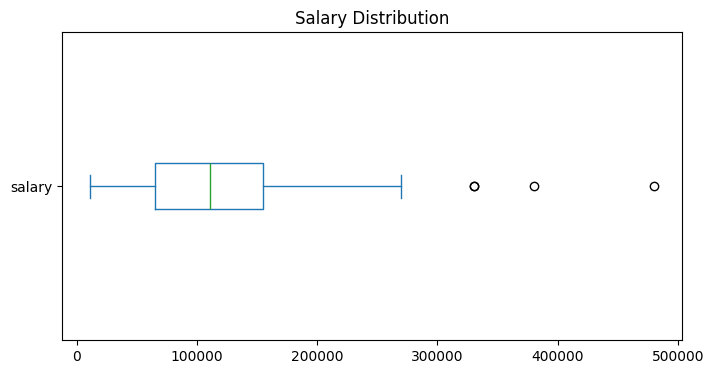

In [19]:
# Plot boxplot for 'salary'
# Chart title: Salary Distribution
# Plot Salary distribution
plt.figure(figsize=(8, 4))
df["salary"].plot(kind="box", vert=False)
plt.title("Salary Distribution")
plt.show()

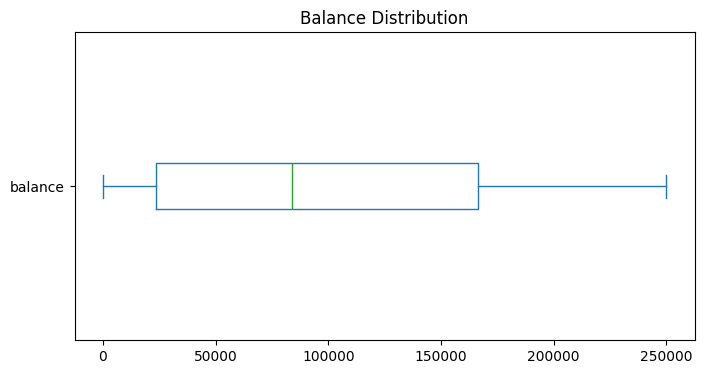

In [20]:
# Plot boxplot for 'balance'
# Chart title: Balance Distribution 
plt.figure(figsize=(8, 4))
df["balance"].plot(kind="box", vert=False)
plt.title("Balance Distribution")
plt.show()

In [21]:
# TODO 6.4 : Identify and count outliers in salary using IQR method
 #  Calculate IQR for Salary
Q1 = df["salary"].quantile(0.25) 
Q3 = df["salary"].quantile(0.75)
IQR = Q3 - Q1

# Define outlier thresholds
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

# Identify outliers
salary_outliers = df[(df["salary"] < lower_bound) | (df["salary"] > upper_bound)]

print("Outlier Customers Based on Salary:")
print(salary_outliers[["salary"]])

outlier_count = ((df["salary"] < lower_bound) | (df["salary"] > upper_bound)).sum()
print("Count of Outlier Customers Based on Salary:", outlier_count)

Outlier Customers Based on Salary:
      salary
2   330000.0
36  480000.0
46  330000.0
59  380000.0
Count of Outlier Customers Based on Salary: 4


In [22]:
# Cap salary outliers at the upper bound
import numpy as np
df["salary"] = np.where(df["salary"] > upper_bound, upper_bound, df["salary"])

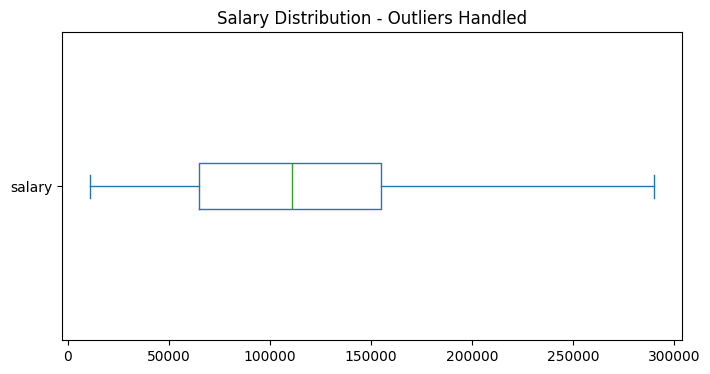

In [23]:

# Plot Salary distribution after handling outiers
# Chart title: Salary Distribution - Outliers Handled

# Plot Salary distribution
plt.figure(figsize=(8, 4))
df["salary"].plot(kind="box", vert=False)
plt.title("Salary Distribution - Outliers Handled")
plt.show()


# Exploratory Data Analysis

In [24]:
# TODO 1: Calculate Basic Summary Statistics
# Compute the mean and median for key numeric columns: Salary , Balance and Credit Score
# Print the results for interpretation.
# TODO 1: Calculate Basic Summary Statistics
numeric_cols = ['salary', 'balance', 'credit_score']

for col in numeric_cols:
    mean_val = df[col].mean()
    median_val = df[col].median()
    print(f"{col.capitalize()}: Mean = {mean_val:.2f}, Median = {median_val:.2f}")

Salary: Mean = 110152.40, Median = 111000.00
Balance: Mean = 96957.79, Median = 84080.87
Credit_score: Mean = 669.51, Median = 683.00


gender
Male      9028
Female    5965
Name: count, dtype: int64
card_type
SILVER            4366
GOLD              4033
PLATINUM          3398
NOT APPLICABLE    3196
Name: count, dtype: int64
hasloan
0    11520
1     3473
Name: count, dtype: int64
hasfd
0    8355
1    6638
Name: count, dtype: int64


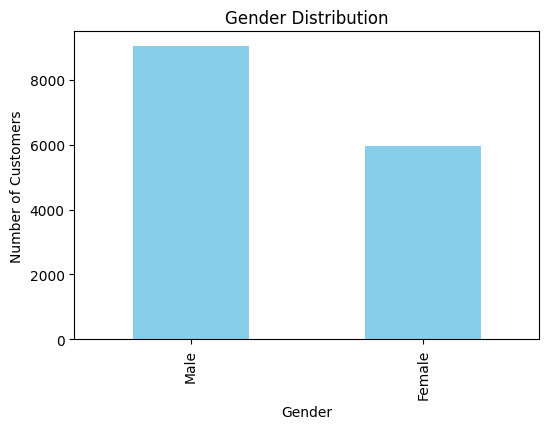

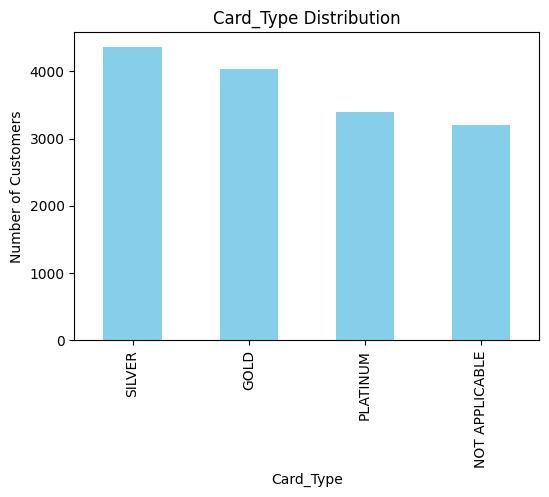

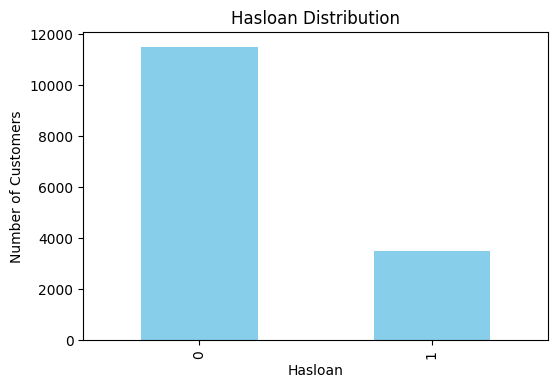

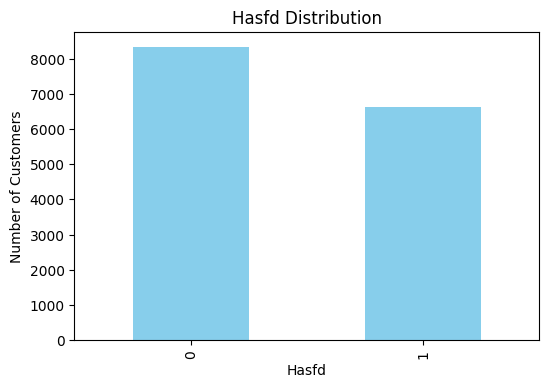

In [25]:
# TODO 2: Understand Categorical Variables
# Count and display how many customers fall into each category of: Gender, Card Type, HasLoan, HasFD
# TODO 2: Understand Categorical Variables
categorical_cols = ['gender', 'card_type', 'hasloan', 'hasfd']

for col in categorical_cols:
    print(df[col].value_counts())

    # Optional: Bar plot for visualization
    plt.figure(figsize=(6, 4))
    df[col].value_counts().plot(kind='bar', color='skyblue')
    plt.title(f'{col.title()} Distribution')
    plt.xlabel(col.title())
    plt.ylabel('Number of Customers')
plt.show()

In [26]:
# TODO 2.2 : PLot the above count distribution --> Optional 


In [ ]:
# TODO 3: Create a boxplot for the Balance column to detect outliers and understand spread.
# TODO 3: Visualize Balance Distributions using a boxplot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['balance'], color='orange')
plt.title('Balance Distribution')
plt.xlabel('Balance')
plt.show()

In [ ]:
# TODO 4 :
# Select a random sample of 200 customers from the dataset.
# Plot scatter plots to explore how two numeric variables relate to each other, plot for Credit Score vs Balance
# TODO 4: Scatter plot - Credit Score vs Balance for a random sample of 200 customers
import seaborn as sns
import matplotlib.pyplot as plt

# Select a random sample of 200 customers
sample_df = df.sample(n=200, random_state=42)

# Scatter plot
plt.figure(figsize=(8, 5))
sns.scatterplot(x='credit_score', y='balance', data=sample_df, color='green')
plt.title('Credit Score vs Balance')
plt.xlabel('Credit Score')
plt.ylabel('Balance')
plt.show()

## Feature Engineering

In [ ]:
# TODO 5.1: Add the following new columns to the dataset:
# Debt-to-Income Ratio
#  Formula: (Balance + (HasLoan × Salary × 0.3)) / Salary
# TODO 5.1: Create Debt-to-Income Ratio column
df['debt_to_income_ratio'] = (df['balance'] + (df['hasloan'] * df['salary'] * 0.3)) / df['salary']

# Preview the new column
print(df[['balance', 'salary', 'hasloan', 'debt_to_income_ratio']].head())

In [ ]:
# TODO 5.2: Create new column calculating Loyalty Score
# Formula: (Tenure × Satisfaction Score) / (1 + Count of Complains)
# TODO 5.2: Create Loyalty Score column
df['loyalty_score'] = (df['tenure'] * df['satisfaction_score']) / (1 + df['count_of_complains'])

# Preview the new column
print(df[['tenure', 'satisfaction_score', 'count_of_complains', 'loyalty_score']].head())

## Analyze Complaints by State

In [ ]:
# TODO 6.1 Compute the average number of complaints per state using groupby() and transform().
# TODO 6.1: Compute the average number of complaints per state
df['avg_of_complaints'] = df.groupby('state')['count_of_complains'].transform('mean')

# Preview the result
print(df[['state', 'count_of_complains', 'avg_of_complaints']].head())

In [ ]:
# TODO 6.2 For each customer, compare their complaint count to their state’s average.
# Create a flag called High Complainer:
# 1 if their complaints are above the state average
# 0 otherwise
# TODO 6.2: Create High Complainer flag
df['high_complainer'] = (df['count_of_complains'] > df['avg_of_complaints']).astype(int)

# Preview the result
print(df[['state', 'count_of_complains', 'avg_of_complaints', 'high_complainer']].head())

In [ ]:
# TODO 6.3 Print first 10 rows with updated data to see the difference
# TODO 6.3: Preview first 10 rows with updated complaints data
print(df[['state', 'count_of_complains', 'avg_of_complaints', 'high_complainer']].head(10))

## Univariate Analysis: Categorize customers by Salary

In [ ]:
# TODO 7: Create a new column called Salary Category with the following buckets:
# Low (≤ 50,000)
# Medium (50,001 – 100,000)
# High (100,001 – 150,000)
# Very High (150,001 – 200,000)
# Above 2 Lakhs (> 200,000)
# Count how many customers fall into each group and plot the result.
# TODO 7: Categorize Customers by Salary
import matplotlib.pyplot as plt

def categorize_salary(s):
    if s <= 50000:
        return 'Low'
    elif s <= 100000:
        return 'Medium'
    elif s <= 150000:
        return 'High'
    elif s <= 200000:
        return 'Very High'
    else:
        return 'Above 2 Lakhs'

# Create the new column
df['salary_category'] = df['salary'].apply(categorize_salary)

# Count customers in each category
salary_counts = df['salary_category'].value_counts()
print("Customer counts by Salary Category:\n", salary_counts)

# Plot the results
plt.figure(figsize=(8, 5))
plt.bar(salary_counts.index, salary_counts.values, color=['lightgreen', 'skyblue', 'orange', 'salmon', 'purple'])
plt.title('Customer Distribution by Salary Category')
plt.xlabel('Salary Category')
plt.ylabel('Number of Customers')
plt.show()

## Compare Customer Segments Using Grouped Statistics

## Bivariate Analysis

In [ ]:
# TODO 8.1: Calculate Average Number of Products Based on Customer Tenure
# TODO 8.1: Average Number of Products Based on Customer Tenure
avg_products_by_tenure = df.groupby('tenure')['num_of_products'].mean().reset_index()

# Preview the result
print("Average Number of Products by Customer Tenure:\n", avg_products_by_tenure.head())

## Multivariate Analysis

In [ ]:
# TODO 8.2:Grouping by churn status to analyze salary and product usage
# TODO 8.2: Group by churn status (exited) to analyze salary and product usage
churn_analysis = df.groupby('exited')[['salary', 'num_of_products']].mean().reset_index()

# Rename columns for clarity
churn_analysis.columns = ['Churn_Status', 'Avg_Salary', 'Avg_Num_Products']

# Preview the result
print("Churn Analysis (Salary and Product Usage):\n",churn_analysis)

In [ ]:
# TODO 8.3: Bar chart to compare salary for exited vs. retained customers
# TODO 8.3: Bar chart to compare average salary for exited vs retained customers
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.bar(['Retained', 'Exited'], churn_analysis['Avg_Salary'], color=['skyblue', 'salmon'])
plt.title('Average Salary - Stayed vs. Exited')
plt.xlabel('Customer Status')
plt.ylabel('Average Salary')
plt.show()


In [ ]:
# TODO 8.4: Bar chart to compare product usage for exited vs. retained customers